In [1]:
# A. AlphaGenome 로드
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import genome, gene_annotation
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components as pc

sys.path.append(str(Path('..').resolve()))
from utils import (
    get_dna_model,
    load_gtf_feather,
    get_sequence_from_ensembl_region,
    normalize_sequence,
    prepare_gtf_views,
    build_transcript_extractors,
)

dna_model = get_dna_model()
gtf = load_gtf_feather()
output_metadata = dna_model.output_metadata(organism=dna_client.Organism.HOMO_SAPIENS)

gtf_transcript, gtf_longest_transcript = prepare_gtf_views(gtf)
_, longest_transcript_extractor = build_transcript_extractors(gtf_transcript, gtf_longest_transcript)
print('Loaded AlphaGenome client + GTF successfully')


gencode.v46.annotation.gtf.gz.feather already exists!
Loaded AlphaGenome client + GTF successfully


In [47]:
# B. HBB/LCR 좌표 확인 + 입력 interval 결정
GENE = 'HBE1'
LCR_CHROM = 'chr11'
LCR_START = 5270791
LCR_END = 5292315
SEQ_LEN = 2**20  # 1Mb

chrom_col = 'Chromosome' if 'Chromosome' in gtf.columns else 'chromosome'
start_col = 'Start' if 'Start' in gtf.columns else 'start'
end_col = 'End' if 'End' in gtf.columns else 'end'
strand_col = 'Strand' if 'Strand' in gtf.columns else 'strand'

gene_row = gtf[(gtf['gene_name'] == GENE) & (gtf['Feature'] == 'transcript')].iloc[0]
chrom = str(gene_row[chrom_col])
start = int(gene_row[start_col])
end = int(gene_row[end_col])
strand = str(gene_row[strand_col])

# gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol=GENE)
gene_interval=genome.Interval(chromosome=chrom, start=start, end=end, strand=strand)
interval = gene_interval.resize(SEQ_LEN)
interval

Interval(chromosome='chr11', start=4744856, end=5793432, strand='-', name='')

In [42]:
ref_seq = normalize_sequence(
    get_sequence_from_ensembl_region(
        species='human',
        chrom=chrom,
        start=LCR_START,
        end=LCR_END,
        strand=1,
        coord_system_version='GRCh38',
    )
)
alt_seq = 'N' * len(ref_seq)
ref_seq[:50]

'CGATATATTAATCAGGCTAGGAGTCAGGGTATATTATTCCTCTAGTGTCC'

In [43]:
variant = genome.Variant(
    chromosome=chrom,
    position=LCR_START,
    reference_bases=ref_seq,
    alternate_bases=alt_seq,
    name='HBB_LCR_all_N',
)

requested_outputs = {dna_client.OutputType.CHIP_HISTONE, dna_client.OutputType.CAGE}
ontology_terms=['EFO:0002067']

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=requested_outputs,
    ontology_terms=['EFO:0002067'],
)

ref = output.reference
alt = output.alternate

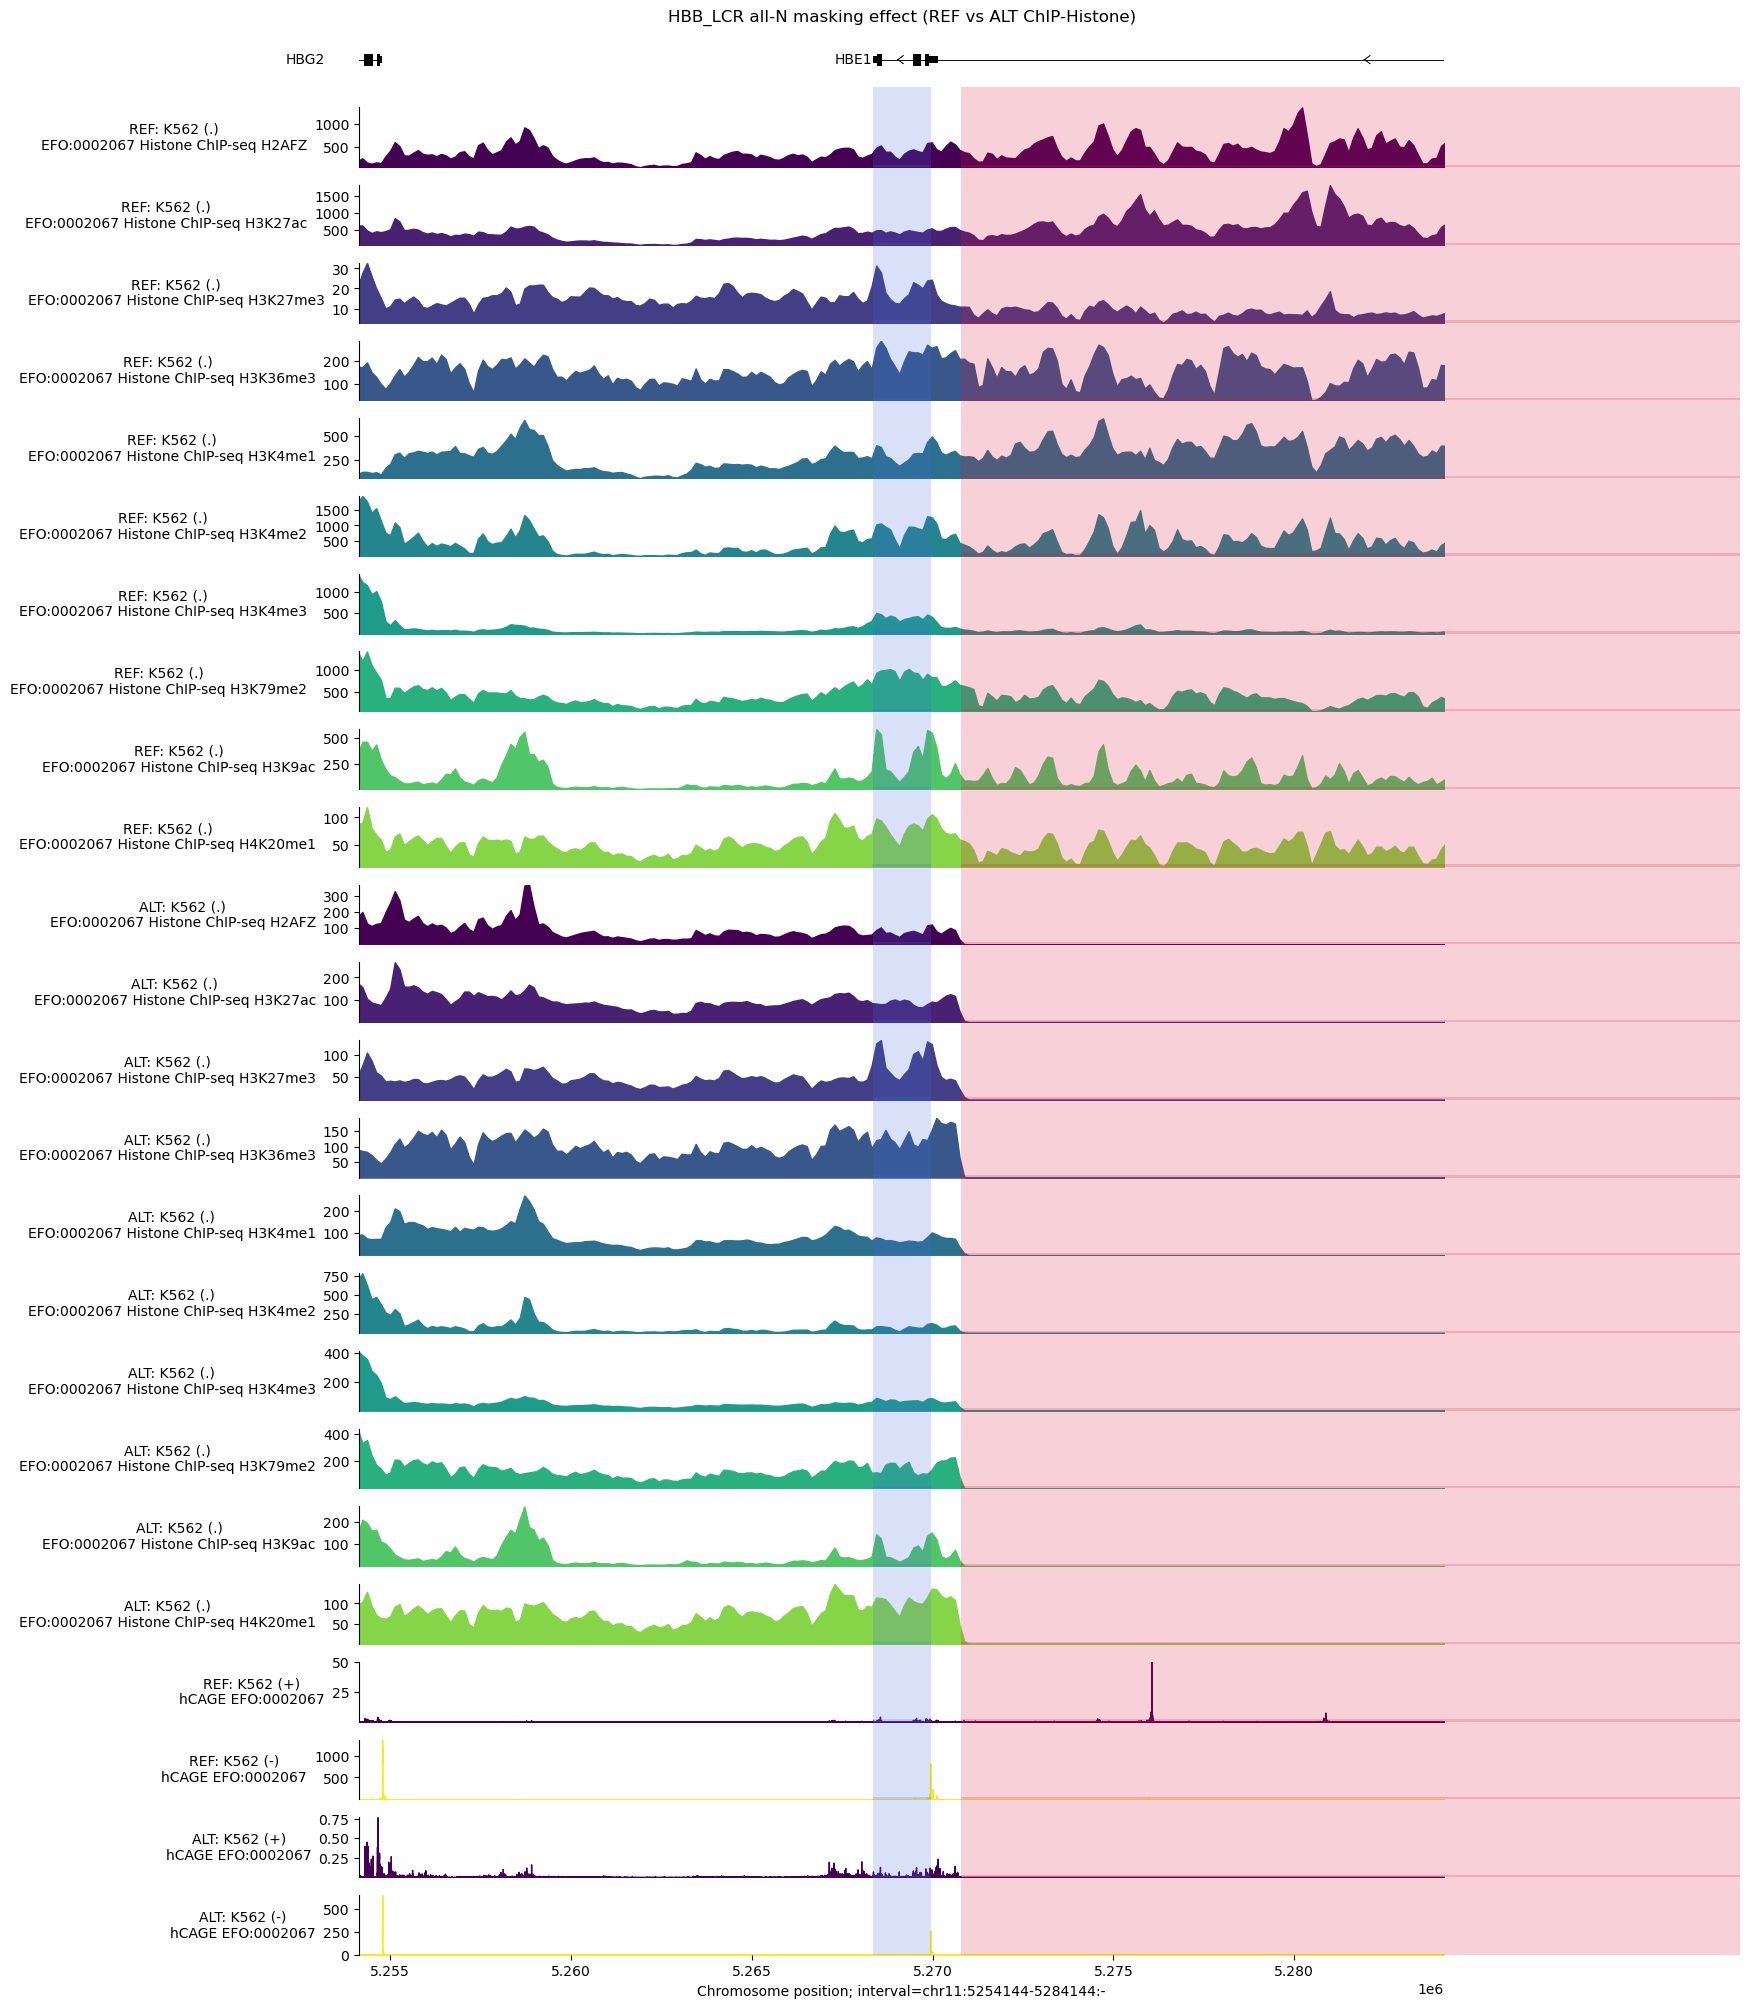

In [44]:
longest_transcripts = longest_transcript_extractor.extract(interval)

annotations = [
    pc.IntervalAnnotation([genome.Interval(chrom, LCR_START, LCR_END, name='HBB_LCR (N-mask)')], colors='crimson', alpha=0.2),
    pc.IntervalAnnotation([genome.Interval(chrom, start, end, name='HBB gene body')], colors='royalblue', alpha=0.2),
]

components = [
    pc.TranscriptAnnotation(longest_transcripts),
    pc.Tracks(ref.chip_histone, filled=True, ylabel_template='REF: {biosample_name} ({strand})\n{name}'),
    pc.Tracks(alt.chip_histone, filled=True, ylabel_template='ALT: {biosample_name} ({strand})\n{name}'),
    pc.Tracks(ref.cage, filled=True, ylabel_template='REF: {biosample_name} ({strand})\n{name}'),
    pc.Tracks(alt.cage, filled=True, ylabel_template='ALT: {biosample_name} ({strand})\n{name}'),
]

_ = pc.plot(
    components,
    # interval=interval_vis,
    interval=interval.resize(30000),
    annotations=annotations,
    title='HBB_LCR all-N masking effect (REF vs ALT ChIP-Histone)',
    fig_width=14,
)


alt: ref 대비 절반으로 줄어듦

In [45]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ref_seq가 없으면 C 셀을 먼저 실행
if 'ref_seq' not in globals():
    raise RuntimeError('ref_seq가 없습니다. 먼저 C. N-치환 variant 생성 셀을 실행하세요.')

alt_seq_random = ''.join(rng.choice(np.array(list('ACGT')), size=len(ref_seq)))
variant_random = genome.Variant(
    chromosome=chrom,
    position=LCR_START,
    reference_bases=ref_seq,
    alternate_bases=alt_seq_random,
    name='HBB_LCR_random_seq',
)

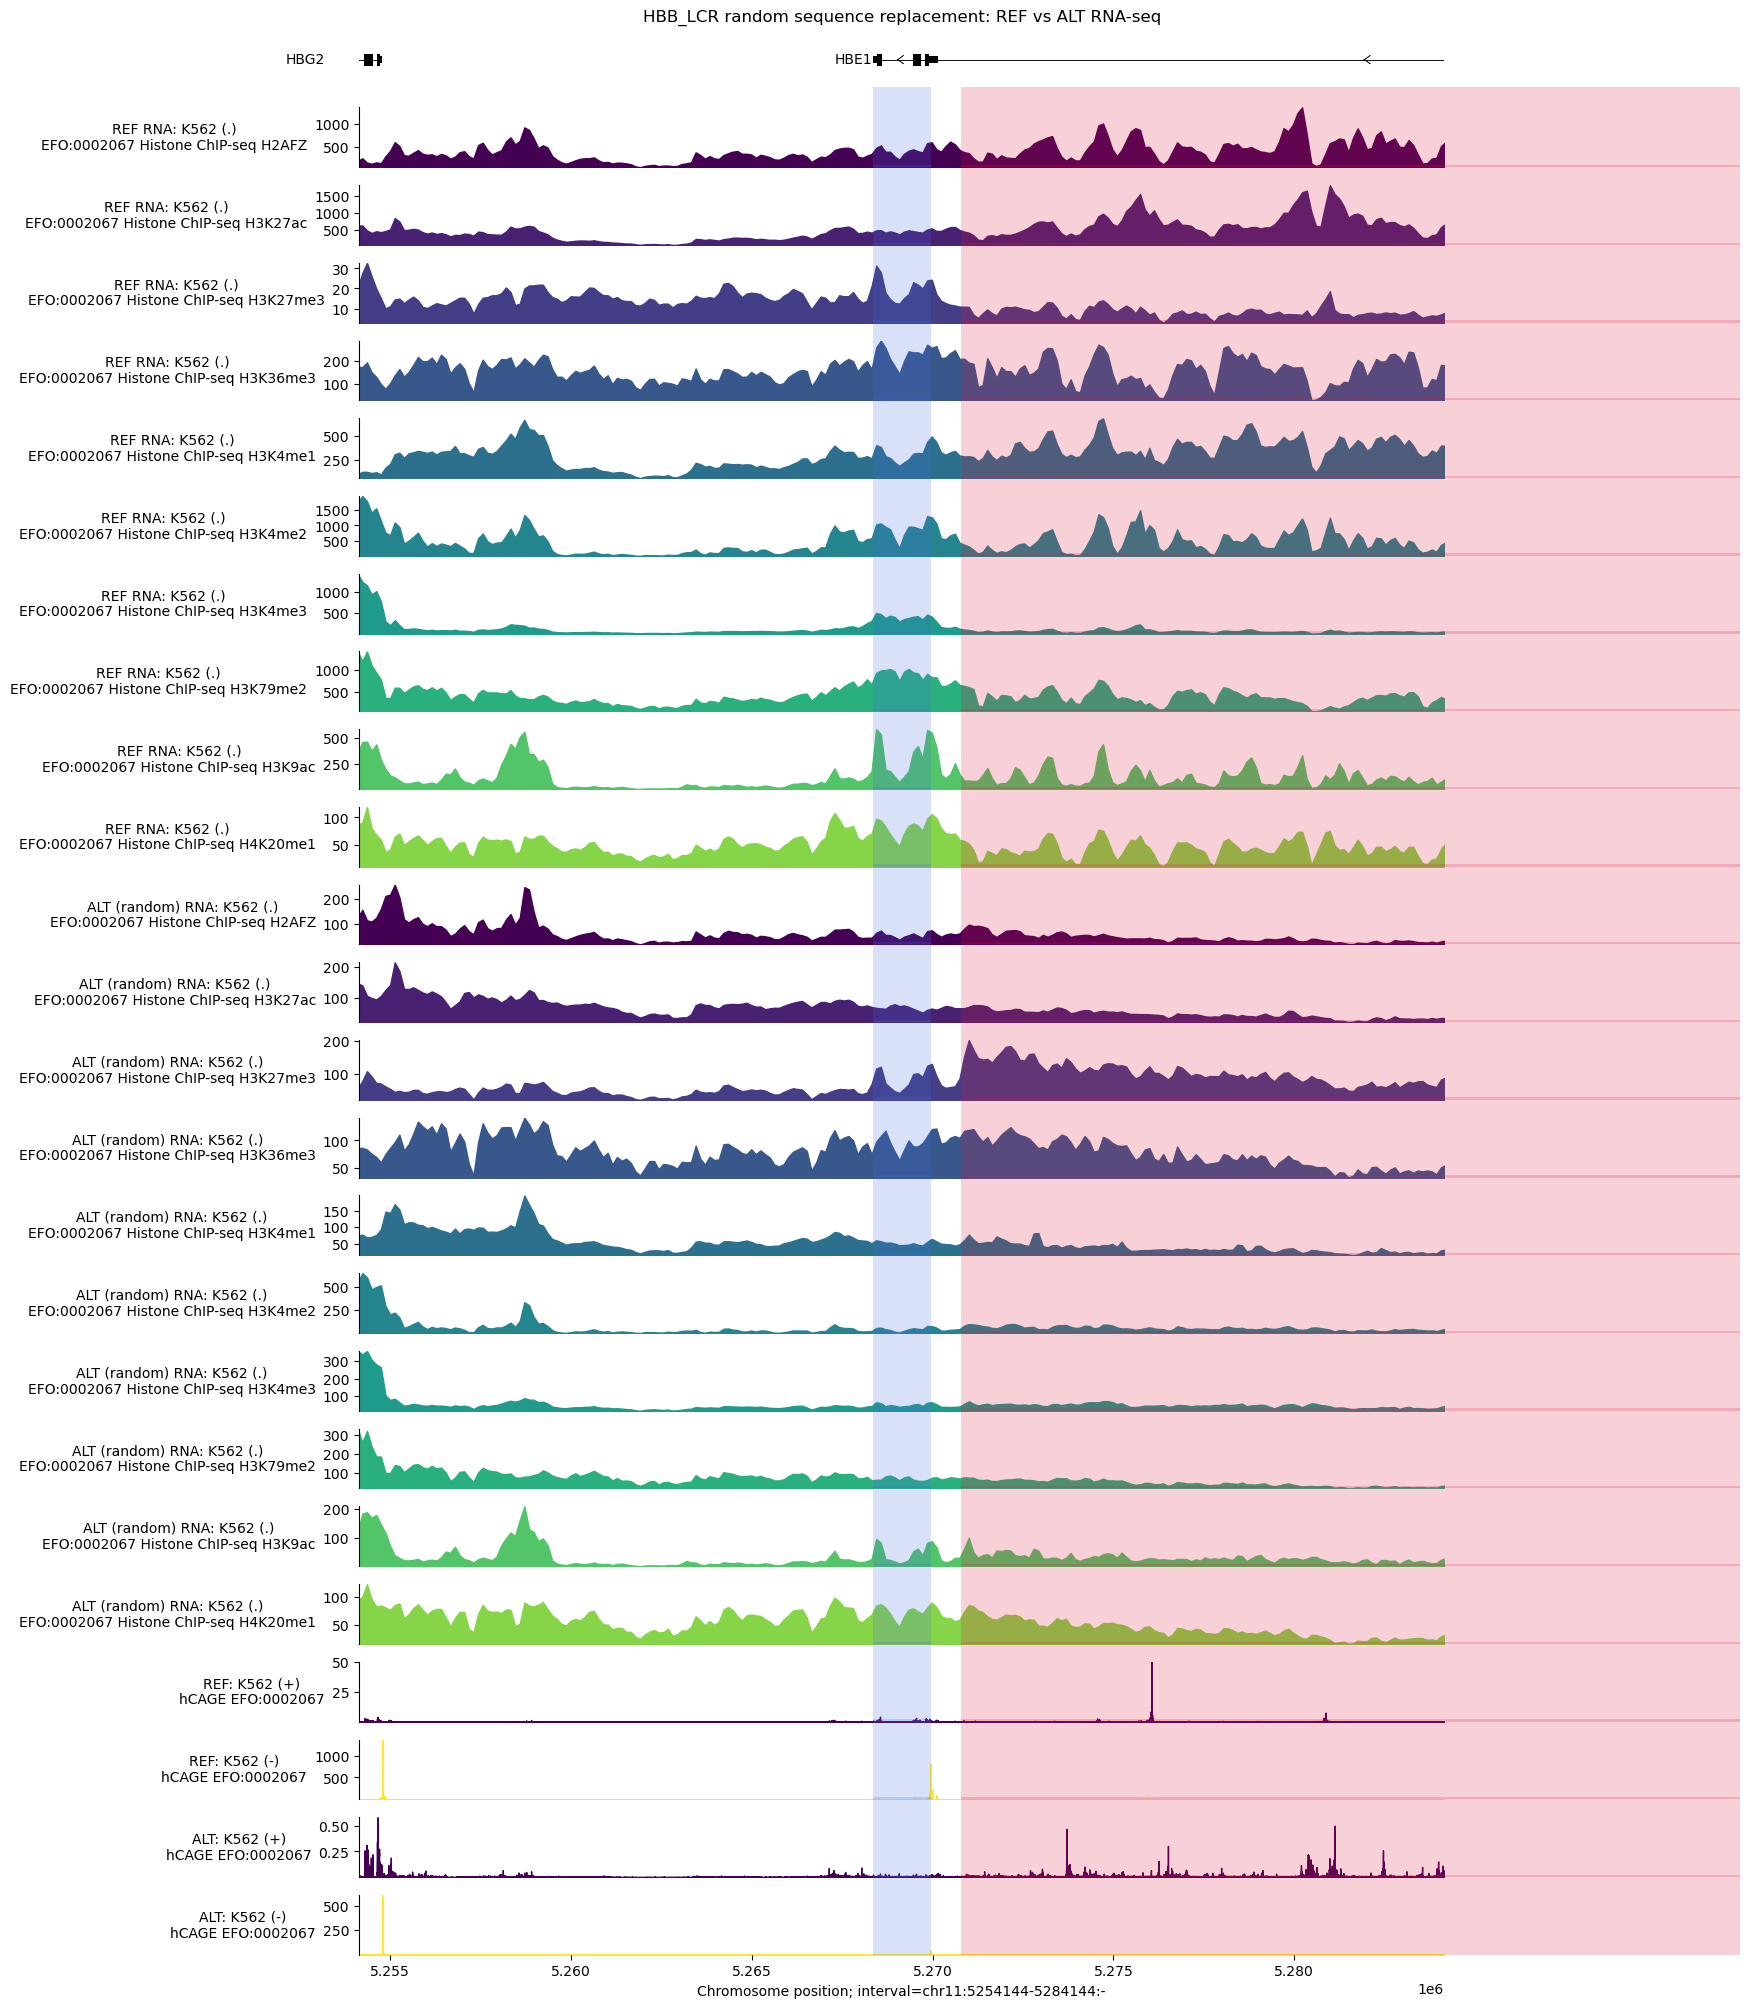

: 

In [ ]:
output_random = dna_model.predict_variant(
    interval=interval,
    variant=variant_random,
    requested_outputs=requested_outputs,
    ontology_terms=ontology_terms,
)

ref_random = output_random.reference
alt_random = output_random.alternate

components_random = [
    pc.TranscriptAnnotation(longest_transcripts),
    pc.Tracks(
        ref_random.chip_histone,
        filled=True,
        ylabel_template='REF RNA: {biosample_name} ({strand})\n{name}'
    ),
    pc.Tracks(
        alt_random.chip_histone,
        filled=True,
        ylabel_template='ALT (random) RNA: {biosample_name} ({strand})\n{name}'
    ),
    pc.Tracks(ref_random.cage, filled=True, ylabel_template='REF: {biosample_name} ({strand})\n{name}'),
    pc.Tracks(alt_random.cage, filled=True, ylabel_template='ALT: {biosample_name} ({strand})\n{name}'),
]

_ = pc.plot(
    components_random,
    interval=interval.resize(30000),
    annotations=annotations,
    title='HBB_LCR random sequence replacement: REF vs ALT RNA-seq',
    fig_width=14,
)
